# FINE speed + GPU `A_h` — compare runs

This notebook is meant to be **opened before the continuation jobs finish**.

1. Run the **`A_h` microbench** cell now (no MAGNET, no forecast). That is the clean GPU vs CPU kernel check.
2. Launch continuation timing from a terminal (commands below). Results land in `outputs/fine_speed_benchmark/<RUN_ID>/`.
3. Re-run the **load timings** cells after jobs complete.

Worktree: `etas-fine-speed-gpu` on `feature/fine-speed-gpu-ah`. Do not `git checkout` in `~/Repos/etas`.

**What is timed**

| Arm | Measures | Needs MAGNET incremental files? |
|-----|----------|----------------------------------|
| `thinning_cpu` / `thinning_gpu` | Ogata thinning + `A_h` (GR magnitudes) | No |
| `FINE_cpu` / `FINE_gpu` | Same + MAGNET magnitudes | Yes |

Timed arms use `--force-rerun` after a shared inversion (and optional MAGNET train) so wall-clock is **forecast only**, not invert/train.

Do **not** set `CUDA_VISIBLE_DEVICES=-1` for GPU `A_h` arms: that hides the device from CuPy. Keep MAGNET/TensorFlow off the GPU by not enabling TF GPU in this process (FINE + GPU `A_h` in one process can still contend; thinning-only is the clean `A_h` comparison).


## Commands (run in a terminal)

Use conda env **`etas_fine_speed_ifs`** (etas worktree + MAGNET `eq_mag_prediction_clean-ifs`).

```bash
cd /home/neriberman/Repos/etas-fine-speed-gpu
export PYTHONPATH="/home/neriberman/Repos/etas-fine-speed-gpu:${PYTHONPATH:-}"
PYTHON=/a/home/cc/students/csguests/neriberman/anaconda3/envs/etas_fine_speed_ifs/bin/python
MAGNET=/home/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean-ifs

# --- A) Legacy vs new FINE (recommended next measurement) ---
# legacy = MAGNET_INCREMENTAL_FEATURE_STATE=0 (build_features each event)
# new    = FeatureState + GrowArray + sliding; writes 4-bucket timer JSON
$PYTHON runnable_code/run_fine_speed_benchmark.py \
  --run-id 20260915_legacy_vs_new \
  --python "$PYTHON" --magnet-root "$MAGNET" \
  --compare-legacy

# Same, but explicit arms (drop GPU if no CUDA for A_h):
# $PYTHON runnable_code/run_fine_speed_benchmark.py --run-id 20260915_legacy_vs_new \
#   --python "$PYTHON" --magnet-root "$MAGNET" \
#   --arms FINE_legacy_cpu,FINE_new_cpu,FINE_new_gpu

# --- B) Faster: reuse MAGNET+inversion from 20260914_speed ---
# mkdir -p outputs/fine_speed_benchmark/20260915_legacy_vs_new
# cp -a outputs/fine_speed_benchmark/20260914_speed/shared \
#   outputs/fine_speed_benchmark/20260915_legacy_vs_new/
# $PYTHON runnable_code/run_fine_speed_benchmark.py --run-id 20260915_legacy_vs_new \
#   --python "$PYTHON" --magnet-root "$MAGNET" --compare-legacy --skip-prepare

# Or append compare arms into the existing baseline run folder:
# $PYTHON runnable_code/run_fine_speed_benchmark.py --run-id 20260914_speed \
#   --python "$PYTHON" --magnet-root "$MAGNET" --compare-legacy --skip-prepare
# (then set RUN_ID="20260914_speed" in the notebook)

# --- C) Original GPU A_h thinning + FINE arms (baseline folder) ---
# $PYTHON runnable_code/run_fine_speed_benchmark.py --run-id 20260914_speed \
#   --python "$PYTHON" --magnet-root "$MAGNET"
# $PYTHON runnable_code/run_fine_speed_benchmark.py --run-id 20260914_speed \
#   --python "$PYTHON" --magnet-root "$MAGNET" --with-fine --arms FINE_cpu,FINE_gpu
```

Outputs:

```
outputs/fine_speed_benchmark/<RUN_ID>/
  timing_summary.jsonl   # wall clock + optional timer_* columns
  timing_summary.csv
  logs/<arm>.log
  logs/<arm>_timers.json # 4-bucket summary for profile=new
  configs/<arm>.json
  shared/inversions/     # reused
  arms/<arm>/...
```

Then set `RUN_ID` / `BASELINE_RUN_ID` in the next cell.


In [25]:
%matplotlib inline
from __future__ import annotations

import json
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "runnable_code" / "run_fine_speed_benchmark.py").is_file():
    if REPO_ROOT.name == "notebooks":
        REPO_ROOT = REPO_ROOT.parent
    else:
        for parent in REPO_ROOT.parents:
            if (parent / "runnable_code" / "run_fine_speed_benchmark.py").is_file():
                REPO_ROOT = parent
                break

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "runnable_code") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "runnable_code"))

os.environ.setdefault("PYTHONPATH", str(REPO_ROOT))

# Primary run to inspect (legacy vs new). None → latest with timing_summary.jsonl.
RUN_ID = "20260915_legacy_vs_new"
# Optional prior GPU A_h baseline for wall-clock overlay.
BASELINE_RUN_ID = "20260914_speed"
RUN_AH_MICROBENCH = True
AH_RESOLUTIONS = (200, 500)
AH_REPEATS = 5
MAGNET_ROOT = Path(
    "/a/home/cc/students/csguests/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean-ifs"
)

BENCH_ROOT = REPO_ROOT / "outputs" / "fine_speed_benchmark"
FIGURE_DIR = REPO_ROOT / "notebooks" / "figures" / "fine_speed_gpu"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

display(Markdown(f"Repo root: `{REPO_ROOT}`"))


Repo root: `/home/neriberman/Repos/etas-fine-speed-gpu`

In [26]:
def latest_run_id(bench_root: Path) -> str | None:
    if not bench_root.is_dir():
        return None
    candidates = sorted(
        (p for p in bench_root.iterdir() if p.is_dir() and (p / "timing_summary.jsonl").is_file()),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    return candidates[0].name if candidates else None


resolved_run_id = RUN_ID or latest_run_id(BENCH_ROOT)
RUN_ROOT = (BENCH_ROOT / resolved_run_id) if resolved_run_id else None
BASELINE_ROOT = (BENCH_ROOT / BASELINE_RUN_ID) if BASELINE_RUN_ID else None
if RUN_ROOT is None:
    display(Markdown(
        "**No continuation timings yet.** Run the terminal command, then re-execute this cell. "
        "The `A_h` microbench below does not need those files."
    ))
else:
    display(Markdown(f"**Run root:** `{RUN_ROOT}`"))
if BASELINE_ROOT is not None and BASELINE_ROOT.is_dir():
    display(Markdown(f"**Baseline root:** `{BASELINE_ROOT}`"))


**Run root:** `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/fine_speed_benchmark/20260915_legacy_vs_new`

**Baseline root:** `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/fine_speed_benchmark/20260914_speed`

## MAGNET incremental files (FINE blocker)


In [27]:
import run_fine_speed_benchmark as speed_bench

missing = speed_bench.magnet_incremental_missing(MAGNET_ROOT)
if missing:
    display(Markdown(
        "FINE FeatureState files are **missing** in the MAGNET working tree "
        f"(`{MAGNET_ROOT}`). Thinning CPU/GPU still works. Do not `git checkout` "
        "those files in the user's MAGNET tree without asking.\n\n"
        + "\n".join(f"- `{MAGNET_ROOT / rel}`" for rel in missing)
    ))
else:
    display(Markdown(f"MAGNET incremental modules present under `{MAGNET_ROOT}`."))


MAGNET incremental modules present under `/a/home/cc/students/csguests/neriberman/Repos/eq_mag_prediction/eq_mag_prediction_clean-ifs`.

## `A_h` microbench (run now)

Times parent-centered `A_h` on the California polygon. Clears `_A_H_CACHE` between CPU and GPU (the cache key does not include backend). GPU sums are not bit-identical; this cell reports `allclose` as well as wall time.

This is **not** a full Ogata loop. After `_A_H_CACHE` is warm, thinning spend is mostly `lambda_s_total` over cached scalars; GPU helps **once per new parent**.


In [28]:
import etas.rate_simulation as rate_simulation
import etas.utility_functions as utility_functions
from shapely.geometry import Polygon

THETA = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
}
MC = 3.6
STRETCH = 3.5


def _cupy_ok() -> bool:
    try:
        import cupy as cp
        return bool(cp.cuda.is_available())
    except Exception:
        return False


def _parents(poly: Polygon) -> list[dict]:
    minx, miny, maxx, maxy = poly.bounds
    cx = 0.5 * (minx + maxx)
    cy = 0.5 * (miny + maxy)
    return [
        {"m": mag, "x": cx, "y": cy, "t": 0.0}
        for mag in (3.6, 4.5, 5.5, 6.0)
    ] + [
        {"m": 4.5, "x": minx + 0.15 * (maxx - minx), "y": cy, "t": 0.0},
        {"m": 4.5, "x": cx, "y": miny + 0.15 * (maxy - miny), "t": 0.0},
    ]


def time_a_h(*, poly, params, parents, resolution: int, use_gpu: bool, repeats: int) -> dict:
    rate_simulation._A_H_CACHE.clear()
    # Warm geometry / kernels once, then time cache-miss repeats by clearing.
    values = []
    elapsed = []
    for _ in range(repeats):
        rate_simulation._A_H_CACHE.clear()
        t0 = time.perf_counter()
        batch = [
            rate_simulation.A_h(
                poly, parent, params, resolution=resolution, stretch=STRETCH, use_gpu=use_gpu
            )
            for parent in parents
        ]
        elapsed.append(time.perf_counter() - t0)
        values.append(batch)
    return {
        "seconds_mean": float(np.mean(elapsed)),
        "seconds_std": float(np.std(elapsed)),
        "values": values[-1],
    }


poly_coords = np.load(REPO_ROOT / "input_data" / "california_shape.npy")
poly = Polygon(poly_coords)
params = utility_functions.expand_theta_log10(dict(THETA))
params["m_c"] = MC
parents = _parents(poly)
gpu_ok = _cupy_ok()
display(Markdown(
    f"Polygon nodes={len(poly_coords)}, parents={len(parents)}, "
    f"CuPy CUDA available={gpu_ok}."
))

ah_rows = []
if RUN_AH_MICROBENCH:
    for resolution in AH_RESOLUTIONS:
        cpu = time_a_h(
            poly=poly, params=params, parents=parents,
            resolution=resolution, use_gpu=False, repeats=AH_REPEATS,
        )
        row = {
            "resolution": resolution,
            "n_parents": len(parents),
            "repeats": AH_REPEATS,
            "cpu_seconds": cpu["seconds_mean"],
            "cpu_seconds_std": cpu["seconds_std"],
            "gpu_seconds": np.nan,
            "gpu_seconds_std": np.nan,
            "speedup": np.nan,
            "max_rel_diff": np.nan,
            "allclose": np.nan,
        }
        if gpu_ok:
            gpu = time_a_h(
                poly=poly, params=params, parents=parents,
                resolution=resolution, use_gpu=True, repeats=AH_REPEATS,
            )
            cpu_v = np.asarray(cpu["values"], dtype=float)
            gpu_v = np.asarray(gpu["values"], dtype=float)
            rel = np.abs(gpu_v - cpu_v) / np.maximum(np.abs(cpu_v), 1e-30)
            row["gpu_seconds"] = gpu["seconds_mean"]
            row["gpu_seconds_std"] = gpu["seconds_std"]
            row["speedup"] = cpu["seconds_mean"] / gpu["seconds_mean"] if gpu["seconds_mean"] else np.nan
            row["max_rel_diff"] = float(np.max(rel))
            row["allclose"] = bool(np.allclose(cpu_v, gpu_v, rtol=1e-10, atol=1e-12))
        ah_rows.append(row)
    ah_df = pd.DataFrame(ah_rows)
    display(ah_df)
    if RUN_ROOT is not None:
        out = RUN_ROOT / "ah_microbench.json"
        out.write_text(ah_df.to_json(orient="records", indent=2), encoding="utf-8")
        display(Markdown(f"Wrote `{out}`"))
    else:
        preview = BENCH_ROOT / "_preview"
        preview.mkdir(parents=True, exist_ok=True)
        out = preview / "ah_microbench.json"
        out.write_text(ah_df.to_json(orient="records", indent=2), encoding="utf-8")
        display(Markdown(f"Wrote preview `{out}` (no RUN_ID yet)"))
else:
    display(Markdown("`RUN_AH_MICROBENCH = False`; skipped."))


Polygon nodes=20, parents=6, CuPy CUDA available=True.

,resolution,n_parents,repeats,cpu_seconds,cpu_seconds_std,gpu_seconds,gpu_seconds_std,speedup,max_rel_diff,allclose
0,200,6,5,0.017179,0.000579,0.010933,0.000364,1.571277,8.777769e-16,True
1,500,6,5,0.166269,0.009308,0.155183,0.048976,1.071437,6.177322e-16,True


Wrote `/home/neriberman/Repos/etas-fine-speed-gpu/outputs/fine_speed_benchmark/20260915_legacy_vs_new/ah_microbench.json`

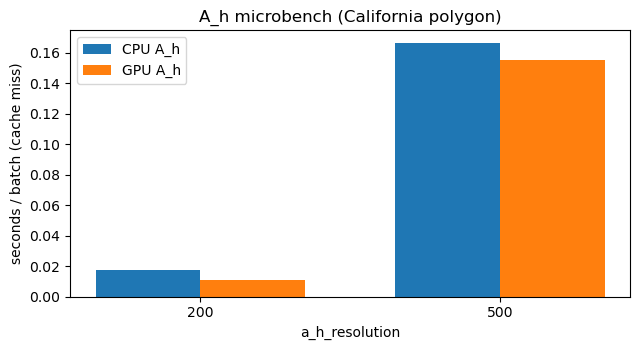

In [29]:
if RUN_AH_MICROBENCH and "ah_df" in globals() and not ah_df.empty:
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    x = np.arange(len(ah_df))
    w = 0.35
    ax.bar(x - w / 2, ah_df["cpu_seconds"], w, label="CPU A_h")
    if ah_df["gpu_seconds"].notna().any():
        ax.bar(x + w / 2, ah_df["gpu_seconds"], w, label="GPU A_h")
    ax.set_xticks(x, [str(v) for v in ah_df["resolution"]])
    ax.set_xlabel("a_h_resolution")
    ax.set_ylabel("seconds / batch (cache miss)")
    ax.set_title("A_h microbench (California polygon)")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / "ah_microbench_bars.png", dpi=140)
    plt.show()


## Legacy vs new FINE

| Arm | Meaning |
|-----|---------|
| `FINE_legacy_cpu` | `MAGNET_INCREMENTAL_FEATURE_STATE=0` (oracle `build_features` each event), CPU `A_h` |
| `FINE_new_cpu` | FeatureState + GrowArray + sliding, CPU `A_h`, 4-bucket timers |
| `FINE_new_gpu` | Same as new + CuPy `A_h` |

Expect **new ≪ legacy** on wall clock when MAGNET features dominate. Event counts need not match across profiles (different feature path → different sampled mags), but should be stable seed-to-seed within a profile.


### All recorded rows (including prepare)

,run_id,arm,method,use_gpu,profile,timed,force_rerun,seed,n_runs,max_forecast_events,...,finished_at,exit_code,wall_seconds,n_events,forecast_catalog,timer_a_h_miss,timer_lambda_s,timer_magnet,timer_other,timer_frac_magnet
0,20260915_legacy_vs_new,FINE_legacy_cpu,FINE,False,legacy,True,True,0,1,500,...,2026-09-15T12:46:29Z,0,45.574,496,/home/neriberman/Repos/etas-fine-speed-gpu/out...,NaN,NaN,NaN,NaN,NaN
1,20260915_legacy_vs_new,FINE_new_cpu,FINE,False,new,True,True,0,1,500,...,2026-09-15T12:47:10Z,0,41.498,496,/home/neriberman/Repos/etas-fine-speed-gpu/out...,12.509418,5.903588,11.683571,3.017887,0.352824
2,20260915_legacy_vs_new,FINE_new_gpu,FINE,True,new,True,True,0,1,500,...,2026-09-15T12:47:46Z,0,36.154,496,/home/neriberman/Repos/etas-fine-speed-gpu/out...,7.050856,5.852093,11.875401,2.993388,0.427607
3,20260915_legacy_vs_new,FINE_legacy_cpu,FINE,False,legacy,True,True,0,1,500,...,2026-09-15T12:56:22Z,0,47.412,496,/home/neriberman/Repos/etas-fine-speed-gpu/out...,NaN,NaN,NaN,NaN,NaN
4,20260915_legacy_vs_new,FINE_new_cpu,FINE,False,new,True,True,0,1,500,...,2026-09-15T12:57:03Z,0,40.790,496,/home/neriberman/Repos/etas-fine-speed-gpu/out...,12.131126,5.932902,11.523881,3.045439,0.353132


### Timed forecast arms (last row per arm)

,run_id,arm,method,use_gpu,profile,timed,force_rerun,seed,n_runs,max_forecast_events,...,finished_at,exit_code,wall_seconds,n_events,forecast_catalog,timer_a_h_miss,timer_lambda_s,timer_magnet,timer_other,timer_frac_magnet
2,20260915_legacy_vs_new,FINE_new_gpu,FINE,True,new,True,True,0,1,500,...,2026-09-15T12:47:46Z,0,36.154,496,/home/neriberman/Repos/etas-fine-speed-gpu/out...,7.050856,5.852093,11.875401,2.993388,0.427607
3,20260915_legacy_vs_new,FINE_legacy_cpu,FINE,False,legacy,True,True,0,1,500,...,2026-09-15T12:56:22Z,0,47.412,496,/home/neriberman/Repos/etas-fine-speed-gpu/out...,NaN,NaN,NaN,NaN,NaN
4,20260915_legacy_vs_new,FINE_new_cpu,FINE,False,new,True,True,0,1,500,...,2026-09-15T12:57:03Z,0,40.790,496,/home/neriberman/Repos/etas-fine-speed-gpu/out...,12.131126,5.932902,11.523881,3.045439,0.353132


### Legacy vs new wall clock

,arm,profile,use_gpu,wall_seconds,n_events,exit_code,timer_a_h_miss,timer_lambda_s,timer_magnet,timer_other,timer_frac_magnet
0,FINE_legacy_cpu,legacy,False,47.412,496,0,NaN,NaN,NaN,NaN,NaN
1,FINE_new_cpu,new,False,40.790,496,0,12.131126,5.932902,11.523881,3.045439,0.353132
2,FINE_new_gpu,new,True,36.154,496,0,7.050856,5.852093,11.875401,2.993388,0.427607


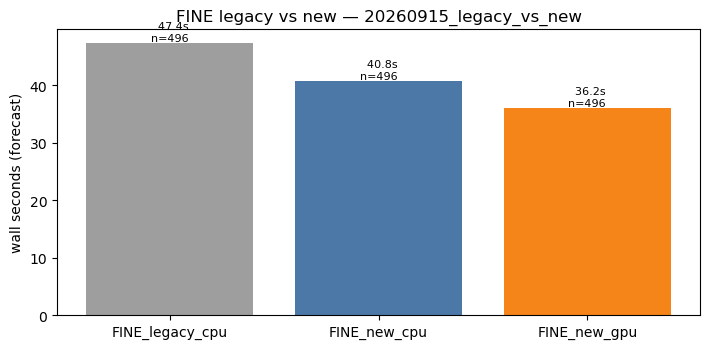

**Speedup legacy/new (CPU):** 1.16×

In [30]:
def load_timing(run_root: Path | None) -> pd.DataFrame:
    if run_root is None:
        return pd.DataFrame()
    path = run_root / "timing_summary.jsonl"
    if not path.is_file():
        return pd.DataFrame()
    rows = [json.loads(line) for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]
    return pd.DataFrame(rows)


def last_timed(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    timed = df.loc[df["timed"] == True].copy() if "timed" in df.columns else df.copy()
    return timed.drop_duplicates(subset=["arm"], keep="last")


timing = load_timing(RUN_ROOT)
baseline_timing = load_timing(BASELINE_ROOT)
timed = last_timed(timing)
baseline_timed = last_timed(baseline_timing)

if timing.empty:
    display(Markdown("No `timing_summary.jsonl` yet. Launch `--compare-legacy` and re-run."))
else:
    display(Markdown("### All recorded rows (including prepare)"))
    display(timing)
    display(Markdown("### Timed forecast arms (last row per arm)"))
    display(timed)

compare_arms = [a for a in ("FINE_legacy_cpu", "FINE_new_cpu", "FINE_new_gpu") if a in set(timed.get("arm", []))]
if len(compare_arms) >= 2:
    sub = timed.set_index("arm").loc[compare_arms]
    display(Markdown("### Legacy vs new wall clock"))
    show_cols = [c for c in ["profile", "use_gpu", "wall_seconds", "n_events", "exit_code",
                             "timer_a_h_miss", "timer_lambda_s", "timer_magnet", "timer_other",
                             "timer_frac_magnet"] if c in sub.columns]
    display(sub[show_cols].reset_index())
    fig, ax = plt.subplots(figsize=(7.2, 3.6))
    ax.bar(compare_arms, sub["wall_seconds"].astype(float), color=["#9e9e9e", "#4c78a8", "#f58518"][: len(compare_arms)])
    ax.set_ylabel("wall seconds (forecast)")
    ax.set_title(f"FINE legacy vs new — {resolved_run_id}")
    for i, arm in enumerate(compare_arms):
        sec = float(sub.loc[arm, "wall_seconds"])
        n_ev = sub.loc[arm, "n_events"] if "n_events" in sub.columns else None
        ax.text(i, sec, f"  {sec:.1f}s\nn={n_ev}", ha="center", va="bottom", fontsize=8)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"legacy_vs_new_{resolved_run_id}.png", dpi=140)
    plt.show()
    if "FINE_legacy_cpu" in sub.index and "FINE_new_cpu" in sub.index:
        leg = float(sub.loc["FINE_legacy_cpu", "wall_seconds"])
        new = float(sub.loc["FINE_new_cpu", "wall_seconds"])
        display(Markdown(f"**Speedup legacy/new (CPU):** {leg / new:.2f}×" if new else "n/a"))
elif not timed.empty:
    display(Markdown("No `FINE_legacy_*` / `FINE_new_*` arms in this run yet — only GPU A_h arms or thinning."))


## 4-bucket timers (new profile only)

Filled when `ETAS_FINE_THINNING_TIMERS=1` (automatic for `FINE_new_*` arms). Buckets: `A_h` miss / `lambda_s_total` / MAGNET / other.


,arm,a_h_miss,lambda_s,magnet,other,frac_magnet,wall_seconds
0,FINE_new_gpu,7.050856,5.852093,11.875401,2.993388,0.427607,36.154
1,FINE_new_cpu,12.131126,5.932902,11.523881,3.045439,0.353132,40.790


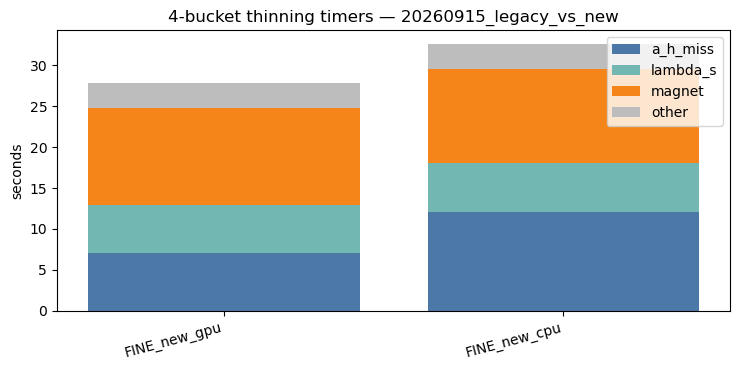

In [31]:
timer_arms = timed.loc[timed["arm"].astype(str).str.contains("new")].copy() if not timed.empty and "arm" in timed.columns else pd.DataFrame()
if timer_arms.empty or "timer_magnet" not in timer_arms.columns or timer_arms["timer_magnet"].isna().all():
    display(Markdown("No timer JSON columns yet. Re-run with `--compare-legacy` (new arms write `logs/<arm>_timers.json`)."))
else:
    rows = []
    for _, r in timer_arms.iterrows():
        rows.append({
            "arm": r["arm"],
            "a_h_miss": r.get("timer_a_h_miss"),
            "lambda_s": r.get("timer_lambda_s"),
            "magnet": r.get("timer_magnet"),
            "other": r.get("timer_other"),
            "frac_magnet": r.get("timer_frac_magnet"),
            "wall_seconds": r.get("wall_seconds"),
        })
    tdf = pd.DataFrame(rows)
    display(tdf)
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    buckets = ["a_h_miss", "lambda_s", "magnet", "other"]
    x = np.arange(len(tdf))
    bottom = np.zeros(len(tdf))
    colors = ["#4c78a8", "#72b7b2", "#f58518", "#bdbdbd"]
    for bucket, color in zip(buckets, colors):
        vals = tdf[bucket].fillna(0).to_numpy(dtype=float)
        ax.bar(x, vals, bottom=bottom, label=bucket, color=color)
        bottom = bottom + vals
    ax.set_xticks(x, tdf["arm"].astype(str).tolist(), rotation=15, ha="right")
    ax.set_ylabel("seconds")
    ax.set_title(f"4-bucket thinning timers — {resolved_run_id}")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"timers_{resolved_run_id}.png", dpi=140)
    plt.show()


## Continuation wall-clock (GPU A_h arms + baseline overlay)


/tmp/ipykernel_1329708/1806521255.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


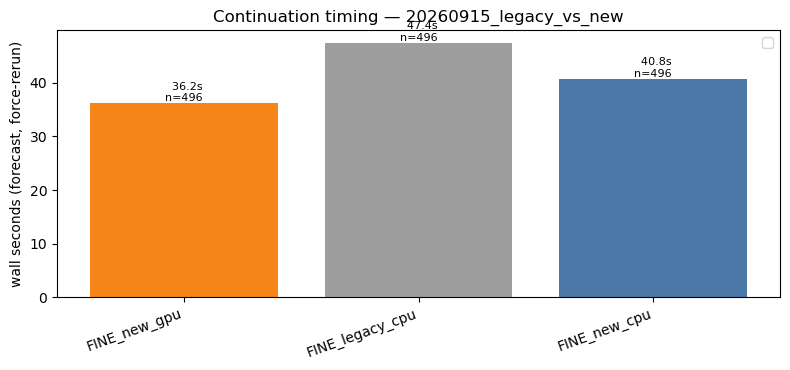

GPU helps **once per new parent**. After `A_h` cache is warm, do not expect Ogata proposals themselves to speed up.

,method,profile,cpu_seconds,gpu_seconds,speedup_cpu_over_gpu,cpu_n_events,gpu_n_events
0,FINE,new,40.79,36.154,1.128229,496,496


In [32]:
if "timed" in globals() and not timed.empty:
    fig, ax = plt.subplots(figsize=(8.0, 3.8))
    labels = timed["arm"].astype(str).tolist()
    values = timed["wall_seconds"].astype(float).tolist()
    colors = []
    for _, row in timed.iterrows():
        if "legacy" in str(row["arm"]):
            colors.append("#9e9e9e")
        elif bool(row.get("use_gpu", False)):
            colors.append("#f58518")
        else:
            colors.append("#4c78a8")
    ax.bar(labels, values, color=colors)
    ax.set_ylabel("wall seconds (forecast, force-rerun)")
    ax.set_title(f"Continuation timing — {resolved_run_id}")
    plt.xticks(rotation=20, ha="right")
    for i, (sec, n_ev) in enumerate(zip(values, timed.get("n_events", [None] * len(values)))):
        ax.text(i, sec, f"  {sec:.1f}s\nn={n_ev}", ha="center", va="bottom", fontsize=8)
    if not baseline_timed.empty:
        base_map = baseline_timed.drop_duplicates("arm", keep="last").set_index("arm")["wall_seconds"]
        for i, arm in enumerate(labels):
            if arm in base_map.index:
                ax.plot([i - 0.35, i + 0.35], [float(base_map.loc[arm])] * 2, color="k", lw=2, label="baseline" if i == 0 else None)
        ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"continuation_wall_{resolved_run_id}.png", dpi=140)
    plt.show()

    speedup_rows = []
    for method, group in timed.groupby("method"):
        if "profile" in group.columns:
            for profile, pg in group.groupby("profile"):
                c = pg.loc[pg["use_gpu"] == False]
                g = pg.loc[pg["use_gpu"] == True]
                if c.empty or g.empty:
                    continue
                cpu_s = float(c["wall_seconds"].iloc[0])
                gpu_s = float(g["wall_seconds"].iloc[0])
                speedup_rows.append({
                    "method": method,
                    "profile": profile,
                    "cpu_seconds": cpu_s,
                    "gpu_seconds": gpu_s,
                    "speedup_cpu_over_gpu": cpu_s / gpu_s if gpu_s else np.nan,
                    "cpu_n_events": c["n_events"].iloc[0],
                    "gpu_n_events": g["n_events"].iloc[0],
                })
        else:
            cpu = group.loc[group["use_gpu"] == False]
            gpu = group.loc[group["use_gpu"] == True]
            if cpu.empty or gpu.empty:
                continue
            cpu_s = float(cpu["wall_seconds"].iloc[0])
            gpu_s = float(gpu["wall_seconds"].iloc[0])
            speedup_rows.append({
                "method": method,
                "cpu_seconds": cpu_s,
                "gpu_seconds": gpu_s,
                "speedup_cpu_over_gpu": cpu_s / gpu_s if gpu_s else np.nan,
                "cpu_n_events": cpu["n_events"].iloc[0],
                "gpu_n_events": gpu["n_events"].iloc[0],
            })
    if speedup_rows:
        display(Markdown("GPU helps **once per new parent**. After `A_h` cache is warm, do not expect Ogata proposals themselves to speed up."))
        display(pd.DataFrame(speedup_rows))
else:
    display(Markdown("Waiting for timed continuation rows."))


## Catalog sanity (CPU vs GPU / legacy vs new)

GPU `A_h` is `allclose`, not bit-identical. **Legacy vs new** can differ in magnitudes (different feature path). Within one profile + seed, CPU vs GPU counts should stay close.


### `FINE_new_cpu` vs `FINE_new_gpu`

Left events=496, right events=496

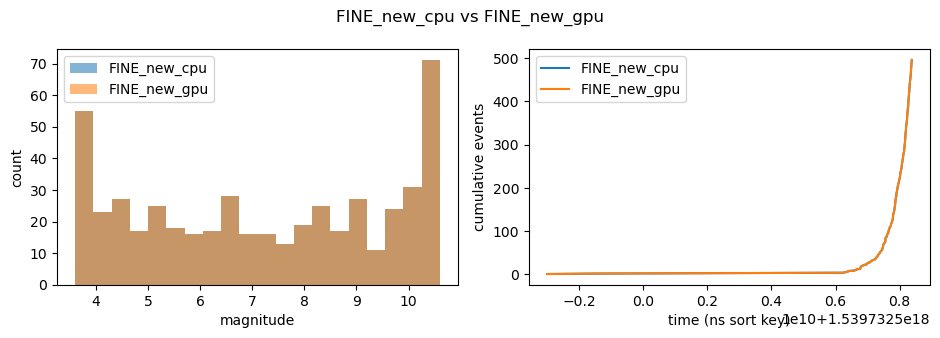

### `FINE_legacy_cpu` vs `FINE_new_cpu`

Left events=496, right events=496

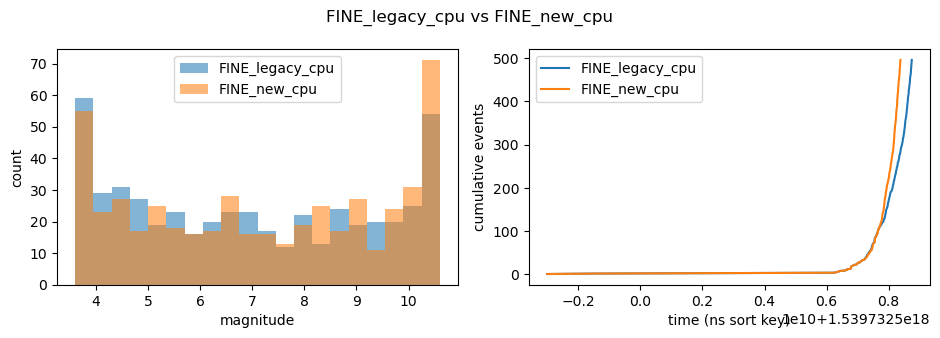

In [33]:
def load_arm_catalog(run_root: Path, arm: str, method: str) -> pd.DataFrame | None:
    path = speed_bench.find_forecast_catalog(run_root / "arms" / arm, method)
    if path is None or not path.is_file():
        return None
    return pd.read_csv(path)


if RUN_ROOT is None:
    display(Markdown("No run root — skip catalog compare."))
else:
    pairs = [
        ("thinning_cpu", "thinning_gpu", "thinning"),
        ("FINE_cpu", "FINE_gpu", "FINE"),
        ("FINE_new_cpu", "FINE_new_gpu", "FINE"),
        ("FINE_legacy_cpu", "FINE_new_cpu", "FINE"),
    ]
    for cpu_arm, gpu_arm, method in pairs:
        cpu_cat = load_arm_catalog(RUN_ROOT, cpu_arm, method)
        gpu_cat = load_arm_catalog(RUN_ROOT, gpu_arm, method)
        if cpu_cat is None and gpu_cat is None:
            continue
        display(Markdown(f"### `{cpu_arm}` vs `{gpu_arm}`"))
        n_cpu = 0 if cpu_cat is None else len(cpu_cat)
        n_gpu = 0 if gpu_cat is None else len(gpu_cat)
        display(Markdown(f"Left events={n_cpu}, right events={n_gpu}"))
        if cpu_cat is None or gpu_cat is None or cpu_cat.empty or gpu_cat.empty:
            continue
        mag_col = "magnitude" if "magnitude" in cpu_cat.columns else "m"
        fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4))
        axes[0].hist(cpu_cat[mag_col], bins=20, alpha=0.55, label=cpu_arm)
        axes[0].hist(gpu_cat[mag_col], bins=20, alpha=0.55, label=gpu_arm)
        axes[0].set_xlabel("magnitude")
        axes[0].set_ylabel("count")
        axes[0].legend()
        t_col = "time" if "time" in cpu_cat.columns else ("dt_days" if "dt_days" in cpu_cat.columns else None)
        if t_col == "time":
            axes[1].plot(np.sort(pd.to_datetime(cpu_cat[t_col]).astype(np.int64)), np.arange(1, n_cpu + 1), label=cpu_arm)
            axes[1].plot(np.sort(pd.to_datetime(gpu_cat[t_col]).astype(np.int64)), np.arange(1, n_gpu + 1), label=gpu_arm)
            axes[1].set_xlabel("time (ns sort key)")
        elif t_col:
            axes[1].plot(np.sort(cpu_cat[t_col]), np.arange(1, n_cpu + 1), label=cpu_arm)
            axes[1].plot(np.sort(gpu_cat[t_col]), np.arange(1, n_gpu + 1), label=gpu_arm)
            axes[1].set_xlabel(t_col)
        if t_col:
            axes[1].set_ylabel("cumulative events")
            axes[1].legend()
        else:
            axes[1].axis("off")
        fig.suptitle(f"{cpu_arm} vs {gpu_arm}")
        fig.tight_layout()
        fig.savefig(FIGURE_DIR / f"catalog_{cpu_arm}_vs_{gpu_arm}_{resolved_run_id}.png", dpi=140)
        plt.show()


## Logs

If an arm failed, open `logs/<arm>.log` under the run root. Prepare rows (`timed=false`) include inversion and MAGNET train and should **not** be used as speedup denominators.

New-profile arms also write `logs/<arm>_timers.json` (4-bucket summary).
